In [1]:
import pandas as pd
import polars as pl
from glob import glob
import seaborn as sns

In [ ]:
df = pd.read_csv("EGRE_DATOS_ABIERTOS_2020.csv", encoding="latin-1") # utf-8 ,delimiter=";" # sep
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'EGRE_DATOS_ABIERTOS_2020.csv'

In [75]:
diseases = pd.read_excel(
    "data/Diccionario BD egresos hospitalario.xlsx",
    sheet_name="codigo CIE-10",
    header=8
)
diseases

,CODIGO SUBCATEGORIA,GLOSA SUBCATEGORIA,CAPITULO,GLOSA CAPITULO,CODIGO GRUPO,GLOSA GRUPO,CODIGO CATEGORIA,GLOSA CATEGORIA
0,A000,"CÓLERA DEBIDO A VIBRIO CHOLERAE O1, BIOTIPO CH...",A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A00,Cólera
1,A001,"CÓLERA DEBIDO A VIBRIO CHOLERAE 01, BIOTIPO EL...",A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A00,Cólera
2,A009,"CÓLERA, NO ESPECIFICADO",A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A00,Cólera
3,A010,FIEBRE TIFOIDEA,A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A01,Fiebres tifoidea y paratifoidea
4,A011,FIEBRE PARATIFOIDEA A,A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A01,Fiebres tifoidea y paratifoidea
...,...,...,...,...,...,...,...,...
12591,U88X,AGENTE BACTERIANO RESISTENTE A MULTIPLES ANTIB...,U00-U99,Códigos para propósitos especiales,U80-U89,Agentes bacterianos resistentes a antibióticos,U80,Agente bacteriano resistente a penicilina y an...
12592,U898,AGENTE BACTERIANO RESISTENTE A OTRO ANTIBIOTIC...,U00-U99,Códigos para propósitos especiales,U80-U89,Agentes bacterianos resistentes a antibióticos,U80,Agente bacteriano resistente a penicilina y an...
12593,U899,AGENTE BACTERIANO RESISTENTE A ANTIBIOTICO NO...,U00-U99,Códigos para propósitos especiales,U80-U89,Agentes bacterianos resistentes a antibióticos,U80,Agente bacteriano resistente a penicilina y an...
12594,U071,"COVID-19, virus identificado",U00-U99,Códigos para propósitos especiales,U00-U49,Asignación provisoria de nuevas afecciones de ...,U07,Uso emergente de U07


In [3]:
df_p = pl.read_csv(
    "data/EGRE_DATOS_ABIERTOS_2020.csv",
    encoding="latin-1",
    separator=";",
    infer_schema=False,
    #infer_schema_length=10_000_000
)

In [4]:
glob("data/EGRE_DATOS_ABIERTOS_*.csv")

['data/EGRE_DATOS_ABIERTOS_2020.csv', 'data/EGRE_DATOS_ABIERTOS_2019.csv']

In [5]:
from glob import glob

output = []
for filepath in glob("data/EGRE_DATOS_ABIERTOS_*.csv"):
    print(filepath)
    frag = pd.read_csv(filepath, delimiter=";", encoding="latin-1")
    frag = frag.rename(columns={"PERTENENCIA_ESTABLECIMIENTO_SALU": "PERTENENCIA_ESTABLECIMIENTO_SALUD"})
    
    output.append(frag)

data/EGRE_DATOS_ABIERTOS_2020.csv


/var/folders/1v/t6n2yxrd4jj986cmzyd911640000gn/T/ipykernel_95259/1310987591.py:6: DtypeWarning: Columns (0: REGION_RESIDENCIA, 1: PREVISION, 2: ANO_EGRESO) have mixed types. Specify dtype option on import or set low_memory=False.
  frag = pd.read_csv(filepath, delimiter=";", encoding="latin-1")


data/EGRE_DATOS_ABIERTOS_2019.csv


In [6]:
df = pd.concat(output)
df["MRUN"] = range(0, df.shape[0])
df.head()

,PERTENENCIA_ESTABLECIMIENTO_SALUD,SEXO,GRUPO_EDAD,ETNIA,GLOSA_PAIS_ORIGEN,COMUNA_RESIDENCIA,GLOSA_COMUNA_RESIDENCIA,REGION_RESIDENCIA,GLOSA_REGION_RESIDENCIA,PREVISION,GLOSA_PREVISION,ANO_EGRESO,DIAG1,DIAG2,DIAS_ESTADA,CONDICION_EGRESO,INTERV_Q,PROCED,MRUN
0,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,1101.0,Iquique,1,De Tarapacá,1,FONASA,2020,Q531,NaN,1,1,1,2,0
1,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,1101.0,Iquique,1,De Tarapacá,1,FONASA,2020,Q173,NaN,1,1,1,2,1
2,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,1101.0,Iquique,1,De Tarapacá,1,FONASA,2020,Z412,NaN,1,1,1,2,2
3,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,1107.0,Alto Hospicio,1,De Tarapacá,1,FONASA,2020,N47X,NaN,1,1,1,2,3
4,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,1101.0,Iquique,1,De Tarapacá,1,FONASA,2020,N47X,NaN,1,1,1,2,4


In [7]:
list(df)

['PERTENENCIA_ESTABLECIMIENTO_SALUD',
 'SEXO',
 'GRUPO_EDAD',
 'ETNIA',
 'GLOSA_PAIS_ORIGEN',
 'COMUNA_RESIDENCIA',
 'GLOSA_COMUNA_RESIDENCIA',
 'REGION_RESIDENCIA',
 'GLOSA_REGION_RESIDENCIA',
 'PREVISION',
 'GLOSA_PREVISION',
 'ANO_EGRESO',
 'DIAG1',
 'DIAG2',
 'DIAS_ESTADA',
 'CONDICION_EGRESO',
 'INTERV_Q',
 'PROCED',
 'MRUN']

In [8]:
df.shape

(2997657, 19)

In [9]:
df.describe().round(1)

,COMUNA_RESIDENCIA,DIAS_ESTADA,CONDICION_EGRESO,INTERV_Q,PROCED,MRUN
count,2997654.0,2997657.0,2997657.0,2997657.0,2997657.0,2997657.0
mean,10598.7,6.2,1.0,1.6,1.9,1498828.0
std,8671.3,49.1,0.2,0.5,0.3,865349.2
min,1101.0,1.0,1.0,1.0,1.0,0.0
25%,7101.0,1.0,1.0,1.0,2.0,749414.0
50%,10301.0,3.0,1.0,2.0,2.0,1498828.0
75%,13122.0,6.0,1.0,2.0,2.0,2248242.0
max,99999.0,16598.0,2.0,2.0,2.0,2997656.0


In [10]:
df["SEXO"].value_counts()

SEXO
MUJER     1701872
HOMBRE    1214398
*           81387
Name: count, dtype: int64

In [11]:
df.groupby("SEXO").agg({"MRUN": "count"})

,MRUN
SEXO,
*,81387
HOMBRE,1214398
MUJER,1701872


In [12]:
df.dtypes

PERTENENCIA_ESTABLECIMIENTO_SALUD        str
SEXO                                     str
GRUPO_EDAD                               str
ETNIA                                    str
GLOSA_PAIS_ORIGEN                        str
COMUNA_RESIDENCIA                    float64
GLOSA_COMUNA_RESIDENCIA                  str
REGION_RESIDENCIA                     object
GLOSA_REGION_RESIDENCIA                  str
PREVISION                             object
GLOSA_PREVISION                          str
ANO_EGRESO                            object
DIAG1                                    str
DIAG2                                    str
DIAS_ESTADA                            int64
CONDICION_EGRESO                       int64
INTERV_Q                               int64
PROCED                                 int64
MRUN                                   int64
dtype: object

In [13]:
df.sort_values("DIAS_ESTADA")

,PERTENENCIA_ESTABLECIMIENTO_SALUD,SEXO,GRUPO_EDAD,ETNIA,GLOSA_PAIS_ORIGEN,COMUNA_RESIDENCIA,GLOSA_COMUNA_RESIDENCIA,REGION_RESIDENCIA,GLOSA_REGION_RESIDENCIA,PREVISION,GLOSA_PREVISION,ANO_EGRESO,DIAG1,DIAG2,DIAS_ESTADA,CONDICION_EGRESO,INTERV_Q,PROCED,MRUN
0,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,1101.0,Iquique,1,De Tarapacá,1,FONASA,2020,Q531,NaN,1,1,1,2,0
119522,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,10 a 19,No se identifica con alguna etnia,Chileno,10101.0,Puerto Montt,10,De Los Lagos,1,FONASA,2019,M233,NaN,1,1,1,2,1449999
119520,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,10 a 19,No se identifica con alguna etnia,Chileno,10107.0,Llanquihue,10,De Los Lagos,1,FONASA,2019,N47X,NaN,1,1,1,2,1449997
119519,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,10 a 19,No se identifica con alguna etnia,Chileno,10201.0,Castro,10,De Los Lagos,1,FONASA,2019,N47X,NaN,1,1,1,2,1449996
119518,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,10 a 19,No se identifica con alguna etnia,Chileno,10202.0,Ancud,10,De Los Lagos,1,FONASA,2019,N47X,NaN,1,1,1,2,1449995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
615101,No Pertenecientes al Sistema Nacional de Servi...,MUJER,40 a 49,No se identifica con alguna etnia,Chileno,13201.0,Puente Alto,13,Metropolitana de Santiago,1,FONASA,2020,U071,NaN,15998,2,2,2,615101
228188,No Pertenecientes al Sistema Nacional de Servi...,MUJER,20 a 29,No se identifica con alguna etnia,Chileno,13201.0,Puente Alto,13,Metropolitana de Santiago,1,FONASA,2020,J960,NaN,16006,2,2,2,228188
473274,No Pertenecientes al Sistema Nacional de Servi...,MUJER,30 a 39,No se identifica con alguna etnia,Chileno,13201.0,Puente Alto,13,Metropolitana de Santiago,1,FONASA,2019,F209,NaN,16286,2,2,2,1803751
146686,Pertenecientes al Sistema Nacional de Servicio...,HOMBRE,10 a 19,No se identifica con alguna etnia,Chileno,8109.0,Santa Juana,8,Del Bíobío,1,FONASA,2019,C259,NaN,16425,1,2,2,1477163


In [14]:
df["EDAD_MAX_DIAS"] = df["GRUPO_EDAD"].copy().replace({
    '1 a 9': 9 * 365,         
    '10 a 19': 19 * 365,
    '20 a 29': 29 * 365,         
    '30 a 39': 39 * 365,
    '40 a 49': 49 * 365,         
    '50 a 59': 59 * 365,         
    '60 a 69': 69 * 365,         
    '70 a 79': 79 * 365,
    '80 a 89': 89 * 365,        
    '90 y más': 120 * 365, 
    'menor de un año': 1 * 365,               
    '*': 120 * 365
})

df = df[df["DIAS_ESTADA"] <= df["EDAD_MAX_DIAS"]].copy()

In [15]:
df["GLOSA_PREVISION"].value_counts()

GLOSA_PREVISION
FONASA         2154118
ISAPRE          580229
*                81387
DIPRECA          45608
NINGUNA          44835
CAPREDENA        36476
DESCONOCIDO      33349
SISA             21588
Name: count, dtype: int64

In [16]:
import numpy as np



<Axes: xlabel='DIAS_ESTADA', ylabel='Count'>

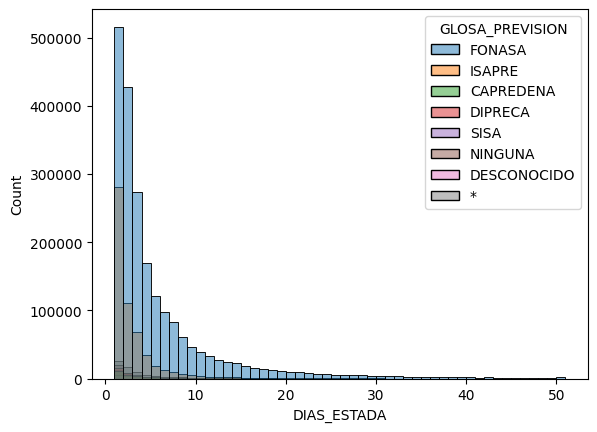

In [17]:
import seaborn as sns

sns.histplot(x="DIAS_ESTADA", bins=50, hue="GLOSA_PREVISION",
    data=df[df["DIAS_ESTADA"] <= np.percentile(df["DIAS_ESTADA"], 99)]
)

<Axes: xlabel='DIAS_ESTADA', ylabel='Density'>

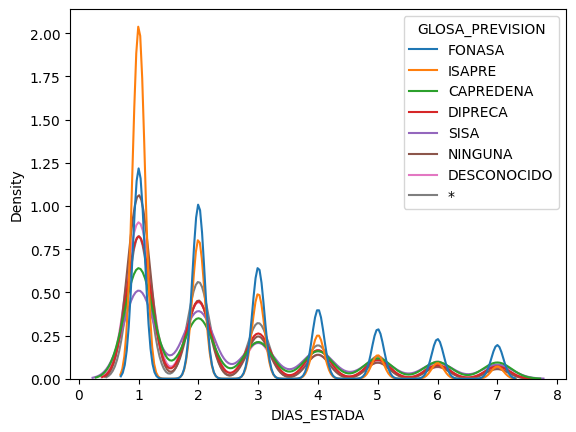

In [18]:
import seaborn as sns

sns.kdeplot(x="DIAS_ESTADA", hue="GLOSA_PREVISION", common_norm=False,
    data=df[df["DIAS_ESTADA"] <= np.percentile(df["DIAS_ESTADA"], 80)]
)

<Axes: xlabel='GLOSA_PREVISION', ylabel='DIAS_ESTADA'>

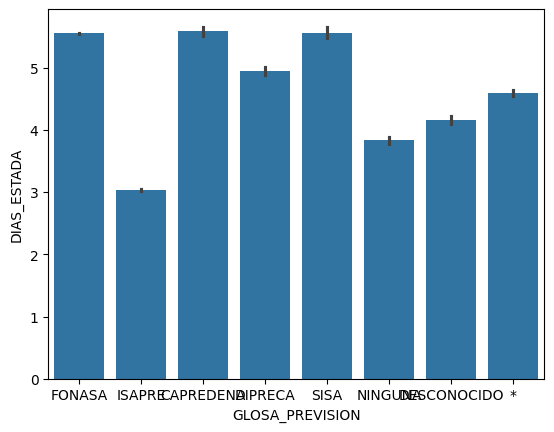

In [19]:
sns.barplot(
    x="GLOSA_PREVISION", 
    y="DIAS_ESTADA", 
    data=df[df["DIAS_ESTADA"] <= np.percentile(df["DIAS_ESTADA"], 99)],
    # order=["ISAPRE", "FONASA", "CAPREDENA", "DIPRECA"]
)

<Axes: xlabel='DIAS_ESTADA'>

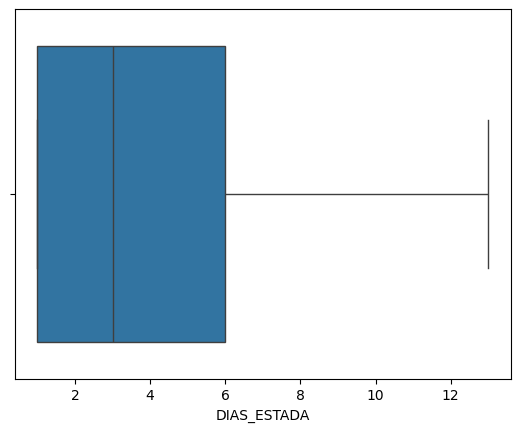

In [20]:
sns.boxplot(x="DIAS_ESTADA", data=df, showfliers=False)

In [21]:
df["GLOSA_COMUNA_RESIDENCIA"].unique()

<StringArray>
[      'Iquique', 'Alto Hospicio',  'Pozo Almonte',          'Pica',
         'Huara',        'Camiña',      'Colchane',   'Antofagasta',
     'Tocopilla',        'Taltal',
 ...
     'Camarones',        'Tortel',  'San Gregorio',     'Río Verde',
 'General Lagos',      'Timaukel',      'Ignorada',    'Extranjero',
 'Laguna Blanca',             nan]
Length: 348, dtype: str

In [22]:
df.query("GLOSA_COMUNA_RESIDENCIA == 'San Pedro de la Paz'")


,PERTENENCIA_ESTABLECIMIENTO_SALUD,SEXO,GRUPO_EDAD,ETNIA,GLOSA_PAIS_ORIGEN,COMUNA_RESIDENCIA,GLOSA_COMUNA_RESIDENCIA,REGION_RESIDENCIA,GLOSA_REGION_RESIDENCIA,PREVISION,GLOSA_PREVISION,ANO_EGRESO,DIAG1,DIAG2,DIAS_ESTADA,CONDICION_EGRESO,INTERV_Q,PROCED,MRUN,EDAD_MAX_DIAS
14340,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8108.0,San Pedro de la Paz,8,Del Bíobío,1,FONASA,2020,N47X,NaN,1,1,1,2,14340,3285
14348,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8108.0,San Pedro de la Paz,8,Del Bíobío,1,FONASA,2020,N47X,NaN,1,1,1,2,14348,3285
14359,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8108.0,San Pedro de la Paz,8,Del Bíobío,1,FONASA,2020,J353,NaN,1,1,1,2,14359,3285
14373,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8108.0,San Pedro de la Paz,8,Del Bíobío,1,FONASA,2020,J353,NaN,1,1,1,2,14373,3285
14382,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8108.0,San Pedro de la Paz,8,Del Bíobío,1,FONASA,2020,N47X,NaN,1,1,1,2,14382,3285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1662441,*,*,*,*,*,8108.0,San Pedro de la Paz,*,*,*,*,*,C509,NaN,1,1,2,2,2992918,43800
1665629,*,*,*,*,*,8108.0,San Pedro de la Paz,*,*,*,*,*,G406,NaN,18,1,2,2,2996106,43800
1666370,*,*,*,*,*,8108.0,San Pedro de la Paz,*,*,*,*,*,M331,NaN,22,1,1,1,2996847,43800
1666954,*,*,*,*,*,8108.0,San Pedro de la Paz,*,*,*,*,*,K402,NaN,1,1,1,2,2997431,43800


In [23]:
df[(df["GLOSA_COMUNA_RESIDENCIA"] == "Concepción")
 | (df["GLOSA_COMUNA_RESIDENCIA"] == "Santiago") | \
    (df["GLOSA_COMUNA_RESIDENCIA"] == "Tucapel")]

,PERTENENCIA_ESTABLECIMIENTO_SALUD,SEXO,GRUPO_EDAD,ETNIA,GLOSA_PAIS_ORIGEN,COMUNA_RESIDENCIA,GLOSA_COMUNA_RESIDENCIA,REGION_RESIDENCIA,GLOSA_REGION_RESIDENCIA,PREVISION,GLOSA_PREVISION,ANO_EGRESO,DIAG1,DIAG2,DIAS_ESTADA,CONDICION_EGRESO,INTERV_Q,PROCED,MRUN,EDAD_MAX_DIAS
14338,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8101.0,Concepción,8,Del Bíobío,1,FONASA,2020,G800,NaN,111,1,2,2,14338,3285
14339,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8101.0,Concepción,8,Del Bíobío,1,FONASA,2020,N289,NaN,5,1,1,2,14339,3285
14343,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8101.0,Concepción,8,Del Bíobío,1,FONASA,2020,K409,NaN,1,1,1,2,14343,3285
14349,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8101.0,Concepción,8,Del Bíobío,1,FONASA,2020,Q539,NaN,1,1,1,2,14349,3285
14354,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8101.0,Concepción,8,Del Bíobío,1,FONASA,2020,N47X,NaN,1,1,1,2,14354,3285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1666986,*,*,*,*,*,8101.0,Concepción,*,*,*,*,*,S720,Y339,5,1,2,2,2997463,43800
1666993,*,*,*,*,*,8101.0,Concepción,*,*,*,*,*,S720,W010,6,1,1,2,2997470,43800
1666996,*,*,*,*,*,8101.0,Concepción,*,*,*,*,*,J449,NaN,5,1,2,2,2997473,43800
1667008,*,*,*,*,*,8101.0,Concepción,*,*,*,*,*,K659,NaN,13,1,2,2,2997485,43800


In [70]:
granccp = df[df["GLOSA_COMUNA_RESIDENCIA"].isin([
    "Concepción", 
    "Talcahuano", 
    "Hualpén",
    "Tomé",
    "Penco",
    "Chiguayante",
    "Hualqui",
    "San Pedro de la Paz",
    "Coronel",
    "Lota",
    "Santa Juana",
    "San Rosendo",
    "Cabrero",
    "Yumbel",
    "Laja",
    "Los Ángeles"
])]
granccp.head()

,PERTENENCIA_ESTABLECIMIENTO_SALUD,SEXO,GRUPO_EDAD,ETNIA,GLOSA_PAIS_ORIGEN,COMUNA_RESIDENCIA,GLOSA_COMUNA_RESIDENCIA,REGION_RESIDENCIA,GLOSA_REGION_RESIDENCIA,PREVISION,GLOSA_PREVISION,ANO_EGRESO,DIAG1,DIAG2,DIAS_ESTADA,CONDICION_EGRESO,INTERV_Q,PROCED,MRUN,EDAD_MAX_DIAS
14337,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8107.0,Penco,8,Del Bíobío,1,FONASA,2020,L031,NaN,3,1,2,2,14337,3285
14338,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8101.0,Concepción,8,Del Bíobío,1,FONASA,2020,G800,NaN,111,1,2,2,14338,3285
14339,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8101.0,Concepción,8,Del Bíobío,1,FONASA,2020,N289,NaN,5,1,1,2,14339,3285
14340,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8108.0,San Pedro de la Paz,8,Del Bíobío,1,FONASA,2020,N47X,NaN,1,1,1,2,14340,3285
14341,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8110.0,Talcahuano,8,Del Bíobío,1,FONASA,2020,N47X,NaN,1,1,1,2,14341,3285


<Axes: xlabel='DIAS_ESTADA', ylabel='GLOSA_COMUNA_RESIDENCIA'>

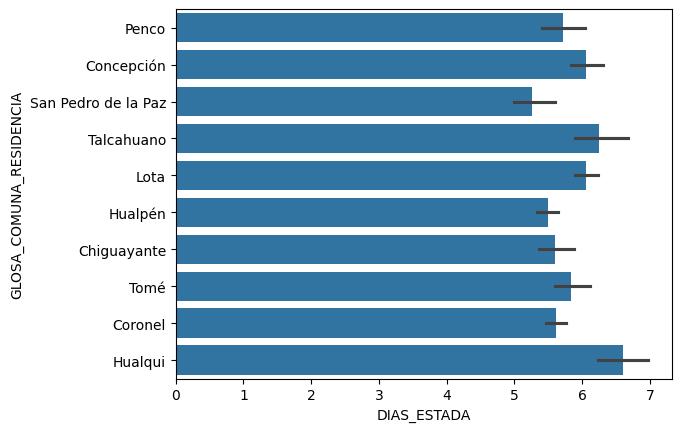

In [26]:
import seaborn as sns
import numpy as np

sns.barplot(
    x="DIAS_ESTADA", 
    y="GLOSA_COMUNA_RESIDENCIA", 
    estimator=np.mean,
    data=granccp
)

<Axes: xlabel='DIAS_ESTADA', ylabel='GLOSA_COMUNA_RESIDENCIA'>

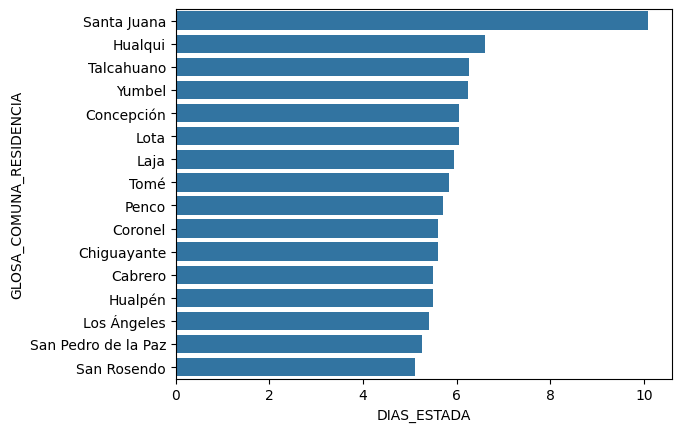

In [71]:
tmp = granccp.groupby("GLOSA_COMUNA_RESIDENCIA")\
    .agg({"DIAS_ESTADA": "mean"})\
    .reset_index()
tmp = tmp.sort_values(by="DIAS_ESTADA", ascending=False)
sns.barplot(
    x="DIAS_ESTADA", 
    y="GLOSA_COMUNA_RESIDENCIA",
    data=tmp
)

<Axes: xlabel='MRUN', ylabel='GLOSA_COMUNA_RESIDENCIA'>

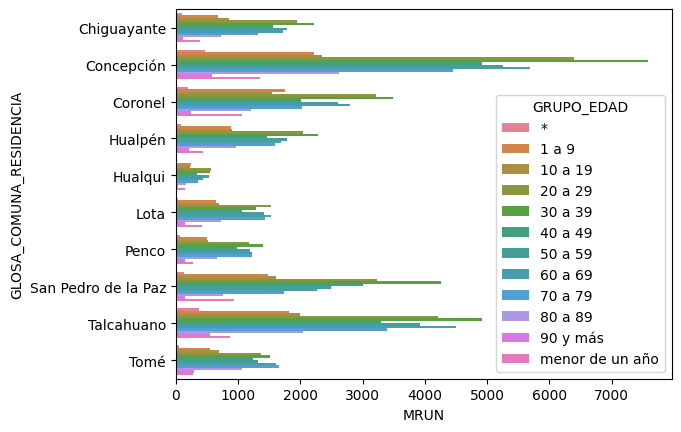

In [28]:
tmp = granccp.groupby(["GLOSA_COMUNA_RESIDENCIA", "GRUPO_EDAD"])\
    .agg({"MRUN": "count"})\
    .reset_index()

sns.barplot(
    x="MRUN", 
    y="GLOSA_COMUNA_RESIDENCIA",
    hue="GRUPO_EDAD",
    data=tmp
)

In [60]:
granccp["GRUPO_EDAD"] = granccp["GRUPO_EDAD"].replace({
    '1 a 9': '0 - 20',         
    '10 a 19': '0 - 20',
    '20 a 29': '20 - 60',         
    '30 a 39': '20 - 60',
         '40 a 49': '20 - 60',         
         '50 a 59': '20 - 60',         
         '60 a 69': '60+',         
         '70 a 79': '60+',
         '80 a 89': '60+',        
         '90 y más': '60+', 
         'menor de un año':  '0 - 20',               
         '*': '*'
})

In [61]:
tmp = granccp.groupby(["GLOSA_COMUNA_RESIDENCIA", "GRUPO_EDAD"])\
    .agg({"MRUN": "count"})

tmp["share"] = tmp.groupby(level=[0])["MRUN"].apply(lambda x: x/x.sum()).values
tmp = tmp.reset_index()
tmp

,GLOSA_COMUNA_RESIDENCIA,GRUPO_EDAD,MRUN,share
0,Chiguayante,*,97,0.007224
1,Chiguayante,0 - 20,1920,0.142985
2,Chiguayante,20 - 60,7520,0.560024
3,Chiguayante,60+,3891,0.289768
4,Concepción,*,466,0.010620
5,Concepción,0 - 20,5923,0.134982
6,Concepción,20 - 60,24152,0.550410
7,Concepción,60+,13339,0.303988
8,Coronel,*,191,0.008623
9,Coronel,0 - 20,4367,0.197147


In [64]:
import plotly.express as px

fig = px.bar(
    tmp,
    x="share", 
    y="GLOSA_COMUNA_RESIDENCIA",
    color="GRUPO_EDAD"
)
fig.update_layout(width=500, height=300)
fig.show()


In [31]:
!pip install plotly

<Axes: xlabel='DIAS_ESTADA', ylabel='GLOSA_COMUNA_RESIDENCIA'>

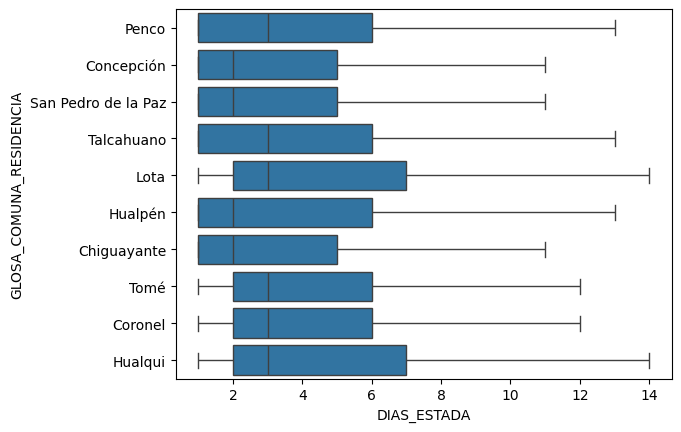

In [32]:
sns.boxplot(
    x="DIAS_ESTADA", 
    y="GLOSA_COMUNA_RESIDENCIA", 
    showfliers=False,
    data=granccp)

In [79]:
granccp.head()

,PERTENENCIA_ESTABLECIMIENTO_SALUD,SEXO,GRUPO_EDAD,ETNIA,GLOSA_PAIS_ORIGEN,COMUNA_RESIDENCIA,GLOSA_COMUNA_RESIDENCIA,REGION_RESIDENCIA,GLOSA_REGION_RESIDENCIA,PREVISION,GLOSA_PREVISION,ANO_EGRESO,DIAG1,DIAG2,DIAS_ESTADA,CONDICION_EGRESO,INTERV_Q,PROCED,MRUN,EDAD_MAX_DIAS
14337,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8107.0,Penco,8,Del Bíobío,1,FONASA,2020,L031,NaN,3,1,2,2,14337,3285
14338,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8101.0,Concepción,8,Del Bíobío,1,FONASA,2020,G800,NaN,111,1,2,2,14338,3285
14339,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8101.0,Concepción,8,Del Bíobío,1,FONASA,2020,N289,NaN,5,1,1,2,14339,3285
14340,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8108.0,San Pedro de la Paz,8,Del Bíobío,1,FONASA,2020,N47X,NaN,1,1,1,2,14340,3285
14341,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8110.0,Talcahuano,8,Del Bíobío,1,FONASA,2020,N47X,NaN,1,1,1,2,14341,3285


In [78]:
diseases.head()

,CODIGO SUBCATEGORIA,GLOSA SUBCATEGORIA,CAPITULO,GLOSA CAPITULO,CODIGO GRUPO,GLOSA GRUPO,CODIGO CATEGORIA,GLOSA CATEGORIA
0,A000,"CÓLERA DEBIDO A VIBRIO CHOLERAE O1, BIOTIPO CH...",A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A00,Cólera
1,A001,"CÓLERA DEBIDO A VIBRIO CHOLERAE 01, BIOTIPO EL...",A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A00,Cólera
2,A009,"CÓLERA, NO ESPECIFICADO",A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A00,Cólera
3,A010,FIEBRE TIFOIDEA,A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A01,Fiebres tifoidea y paratifoidea
4,A011,FIEBRE PARATIFOIDEA A,A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A01,Fiebres tifoidea y paratifoidea


In [83]:
granccp2 = pd.merge(
    granccp,
    diseases,
    left_on="DIAG1",
    right_on="CODIGO SUBCATEGORIA",
    how="left"
)
granccp2.head()

,PERTENENCIA_ESTABLECIMIENTO_SALUD,SEXO,GRUPO_EDAD,ETNIA,GLOSA_PAIS_ORIGEN,COMUNA_RESIDENCIA,GLOSA_COMUNA_RESIDENCIA,REGION_RESIDENCIA,GLOSA_REGION_RESIDENCIA,PREVISION,...,MRUN,EDAD_MAX_DIAS,CODIGO SUBCATEGORIA,GLOSA SUBCATEGORIA,CAPITULO,GLOSA CAPITULO,CODIGO GRUPO,GLOSA GRUPO,CODIGO CATEGORIA,GLOSA CATEGORIA
0,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8107.0,Penco,8,Del Bíobío,1,...,14337,3285,L031,CELULITIS DE OTRAS PARTES DE LOS MIEMBROS,L00-L99,Enfermedades de la piel y del tejido subcutáneo,L00-L08,Infecciones de la piel y del tejido subcutáneo,L03,Celulitis
1,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8101.0,Concepción,8,Del Bíobío,1,...,14338,3285,G800,PARALISIS CEREBRAL ESPASTICA,G00-G99,Enfermedades del sistema nervioso central,G80-G83,Parálisis cerebral y otros síndromes paralíticos,G80,Parálisis cerebral
2,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8101.0,Concepción,8,Del Bíobío,1,...,14339,3285,N289,"TRASTORNO DEL RIÑÓN Y DEL URETER, NO ESPECIFICADO",N00-N99,Enfermedades del sistema genitourinario,N25-N29,Otros trastornos del riñón y del uréter,N28,"Otros trastornos del riñón y del uréter, no cl..."
3,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8108.0,San Pedro de la Paz,8,Del Bíobío,1,...,14340,3285,N47X,"PREPUCIO REDUNDANTE, FIMOSIS Y PARAFIMOSIS",N00-N99,Enfermedades del sistema genitourinario,N40-N51,Enfermedades de los órganos genitales masculinos,N47,"Prepucio redundante, fimosis y parafimosis"
4,No Pertenecientes al Sistema Nacional de Servi...,HOMBRE,1 a 9,No se identifica con alguna etnia,Chileno,8110.0,Talcahuano,8,Del Bíobío,1,...,14341,3285,N47X,"PREPUCIO REDUNDANTE, FIMOSIS Y PARAFIMOSIS",N00-N99,Enfermedades del sistema genitourinario,N40-N51,Enfermedades de los órganos genitales masculinos,N47,"Prepucio redundante, fimosis y parafimosis"


In [87]:
list(granccp2)

['PERTENENCIA_ESTABLECIMIENTO_SALUD',
 'SEXO',
 'GRUPO_EDAD',
 'ETNIA',
 'GLOSA_PAIS_ORIGEN',
 'COMUNA_RESIDENCIA',
 'GLOSA_COMUNA_RESIDENCIA',
 'REGION_RESIDENCIA',
 'GLOSA_REGION_RESIDENCIA',
 'PREVISION',
 'GLOSA_PREVISION',
 'ANO_EGRESO',
 'DIAG1',
 'DIAG2',
 'DIAS_ESTADA',
 'CONDICION_EGRESO',
 'INTERV_Q',
 'PROCED',
 'MRUN',
 'EDAD_MAX_DIAS',
 'CODIGO SUBCATEGORIA',
 'GLOSA SUBCATEGORIA',
 'CAPITULO',
 'GLOSA CAPITULO',
 'CODIGO GRUPO ',
 'GLOSA GRUPO ',
 'CODIGO CATEGORIA',
 'GLOSA CATEGORIA']

In [97]:
for x in list(diseases):
    count = len(diseases[x].unique())
    print(x, count)

CODIGO SUBCATEGORIA 12596
GLOSA SUBCATEGORIA 12580
CAPITULO 22
GLOSA CAPITULO 22
CODIGO GRUPO  262
GLOSA GRUPO  262
CODIGO CATEGORIA 2052
GLOSA CATEGORIA 2048


In [99]:
tmp = granccp2.groupby(["GLOSA_COMUNA_RESIDENCIA", "GLOSA CAPITULO"])\
    .agg({"MRUN": "count"})

tmp["share"] = tmp.groupby(level=[0])["MRUN"].apply(lambda x: x/x.sum()).values
tmp = tmp.reset_index()
tmp

,GLOSA_COMUNA_RESIDENCIA,GLOSA CAPITULO,MRUN,share
0,Cabrero,Ciertas afecciones originadas en el período pe...,90,0.023166
1,Cabrero,Ciertas enfermedades infecciosas y parasitarias,55,0.014157
2,Cabrero,Códigos para propósitos especiales,33,0.008494
3,Cabrero,"Embarazo, parto y puerperio",644,0.165766
4,Cabrero,Enfermedades de la piel y del tejido subcutáneo,74,0.019048
...,...,...,...,...
330,Yumbel,"Malformaciones congénitas, deformidades y anom...",37,0.009827
331,Yumbel,"Síntomas, signos y hallazgos anormales clínico...",82,0.021780
332,Yumbel,Trastornos mentales y del comportamiento,96,0.025498
333,Yumbel,"Traumatismos, envenenamientos y algunas otras ...",454,0.120584


In [ ]:
"])\
    .agg({"MRUN": "count"})

tmp["share"] = tmp.groupby(level=[0])["MRUN"].apply(lambda x: x/x.sum()).values
tmp = tmp.reset_index()
tmp

In [103]:
import plotly.express as px

fig = px.bar(
    tmp,
    x="share", 
    y="GLOSA_COMUNA_RESIDENCIA",
    color="GLOSA CAPITULO"
)
fig.update_layout(width=1200, height=500)
fig.show()


In [129]:
left = df.groupby("DIAG1").agg({"DIAS_ESTADA": "mean"}).reset_index()
left

,DIAG1,DIAS_ESTADA
0,A000,2.500000
1,A009,18.000000
2,A010,8.363636
3,A011,9.666667
4,A012,4.000000
...,...,...
7620,Z978,1.000000
7621,Z980,4.000000
7622,Z981,2.200000
7623,Z988,2.333333


In [130]:
tres = df.groupby("DIAG1").agg({"MRUN": "count"}).reset_index()
tres = tres.rename(columns={"MRUN": "CANTIDAD"})
tres

,DIAG1,CANTIDAD
0,A000,2
1,A009,1
2,A010,121
3,A011,3
4,A012,3
...,...,...
7620,Z978,1
7621,Z980,1
7622,Z981,5
7623,Z988,3


In [131]:
right = df.groupby(["DIAG1", "CONDICION_EGRESO"]).agg({"MRUN": "count"})
right["share"] = right.groupby(level=[0])["MRUN"].apply(lambda x: x/x.sum()).values
right = right.reset_index()
right = right.query("CONDICION_EGRESO == 2")

tmp = pd.merge(left, right, left_on="DIAG1", right_on="DIAG1", how="left")
tmp["share"] = tmp["share"].fillna(0)

tmp = pd.merge(tmp, tres, on="DIAG1")

px.scatter(tmp, x="DIAS_ESTADA", y="share", size="CANTIDAD")